In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
df.shape

(7043, 21)

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [16]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Cleaned Dataset Shape:")
print(df.shape)

Cleaned Dataset Shape:
(7032, 21)


In [18]:
overall_churn = pd.DataFrame({
    "Overall Churn Rate (%)": [round(df["Churn"].mean() * 100, 2)]
})

print(overall_churn)

   Overall Churn Rate (%)
0                   26.58


In [19]:
contract_churn = (
    df.groupby("Contract")
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

contract_churn["ChurnRate"] = round(contract_churn["ChurnRate"] * 100, 2)
print(contract_churn)

         Contract  CustomerCount  ChurnRate
0  Month-to-month           3875      42.71
1        One year           1472      11.28
2        Two year           1685       2.85


In [20]:
payment_churn = (
    df.groupby("PaymentMethod")
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

payment_churn["ChurnRate"] = round(payment_churn["ChurnRate"] * 100, 2)
print(payment_churn)

               PaymentMethod  CustomerCount  ChurnRate
0  Bank transfer (automatic)           1542      16.73
1    Credit card (automatic)           1521      15.25
2           Electronic check           2365      45.29
3               Mailed check           1604      19.20


In [21]:
internet_churn = (
    df.groupby("InternetService")
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

internet_churn["ChurnRate"] = round(internet_churn["ChurnRate"] * 100, 2)

print(internet_churn)

  InternetService  CustomerCount  ChurnRate
0             DSL           2416      19.00
1     Fiber optic           3096      41.89
2              No           1520       7.43


In [22]:
senior_churn = (
    df.groupby("SeniorCitizen")
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

senior_churn["SeniorCitizen"] = senior_churn["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

senior_churn["ChurnRate"] = round(senior_churn["ChurnRate"] * 100, 2)
print(senior_churn)

  SeniorCitizen  CustomerCount  ChurnRate
0    Non-Senior           5890      23.65
1        Senior           1142      41.68


In [25]:
bins = [0, 12, 24, 48, 72]
labels = [
    "0–12 Months",
    "13–24 Months",
    "25–48 Months",
    "49–72 Months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tenure_analysis = (
    df.groupby("TenureGroup")
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

tenure_analysis["ChurnRate"] = round(
    tenure_analysis["ChurnRate"] * 100,
    2
)

print(tenure_analysis)

    TenureGroup  CustomerCount  ChurnRate
0   0–12 Months           2175      47.68
1  13–24 Months           1024      28.71
2  25–48 Months           1594      20.39
3  49–72 Months           2239       9.51


/tmp/ipykernel_3602/1894931604.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TenureGroup")


In [26]:
monthly_charge_analysis = (
    df.groupby("Churn")
    .agg(
        AverageMonthlyCharges=("MonthlyCharges", "mean")
    )
    .reset_index()
)
monthly_charge_analysis["Churn"] = monthly_charge_analysis["Churn"].map({
    0: "Non-Churned",
    1: "Churned"
})
monthly_charge_analysis["AverageMonthlyCharges"] = round(
    monthly_charge_analysis["AverageMonthlyCharges"],
    2
)
print(monthly_charge_analysis)

         Churn  AverageMonthlyCharges
0  Non-Churned                  61.31
1      Churned                  74.44


In [27]:
contract_internet_analysis = (
    df.groupby(["Contract", "InternetService"])
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

contract_internet_analysis["ChurnRate"] = round(
    contract_internet_analysis["ChurnRate"] * 100,
    2
)

print(contract_internet_analysis)

         Contract InternetService  CustomerCount  ChurnRate
0  Month-to-month             DSL           1223      32.22
1  Month-to-month     Fiber optic           2128      54.61
2  Month-to-month              No            524      18.89
3        One year             DSL            570       9.30
4        One year     Fiber optic            539      19.29
5        One year              No            363       2.48
6        Two year             DSL            623       1.93
7        Two year     Fiber optic            429       7.23
8        Two year              No            633       0.79


In [28]:
tenure_contract_analysis = (
    df.groupby(["Contract", "Churn"])
    .agg(
        AverageTenure=("tenure", "mean")
    )
    .reset_index()
)

tenure_contract_analysis["Churn"] = tenure_contract_analysis["Churn"].map({
    0: "Non-Churned",
    1: "Churned"
})

tenure_contract_analysis["AverageTenure"] = round(
    tenure_contract_analysis["AverageTenure"],
    2
)

print(tenure_contract_analysis)

         Contract        Churn  AverageTenure
0  Month-to-month  Non-Churned          21.03
1  Month-to-month      Churned          14.02
2        One year  Non-Churned          41.71
3        One year      Churned          44.96
4        Two year  Non-Churned          56.95
5        Two year      Churned          61.27


In [29]:
risk_profiles = (
    df.groupby([
        "Contract",
        "InternetService",
        "PaymentMethod",
        "SeniorCitizen",
        "TenureGroup"
    ])
    .agg(
        CustomerCount=("customerID", "count"),
        ChurnRate=("Churn", "mean")
    )
    .reset_index()
)

risk_profiles["SeniorCitizen"] = risk_profiles["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

risk_profiles["ChurnRate"] = round(
    risk_profiles["ChurnRate"] * 100,
    2
)

risk_profiles = risk_profiles[risk_profiles["CustomerCount"] >= 20]

top_risk_profiles = risk_profiles.sort_values(
    by=["ChurnRate", "CustomerCount"],
    ascending=[False, False]
).head(3)

print(top_risk_profiles)

          Contract InternetService              PaymentMethod SeniorCitizen  \
32  Month-to-month     Fiber optic  Bank transfer (automatic)    Non-Senior   
60  Month-to-month     Fiber optic               Mailed check        Senior   
52  Month-to-month     Fiber optic           Electronic check        Senior   

    TenureGroup  CustomerCount  ChurnRate  
32  0–12 Months             73      82.19  
60  0–12 Months             23      78.26  
52  0–12 Months            171      73.10  


/tmp/ipykernel_3602/1379127928.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([


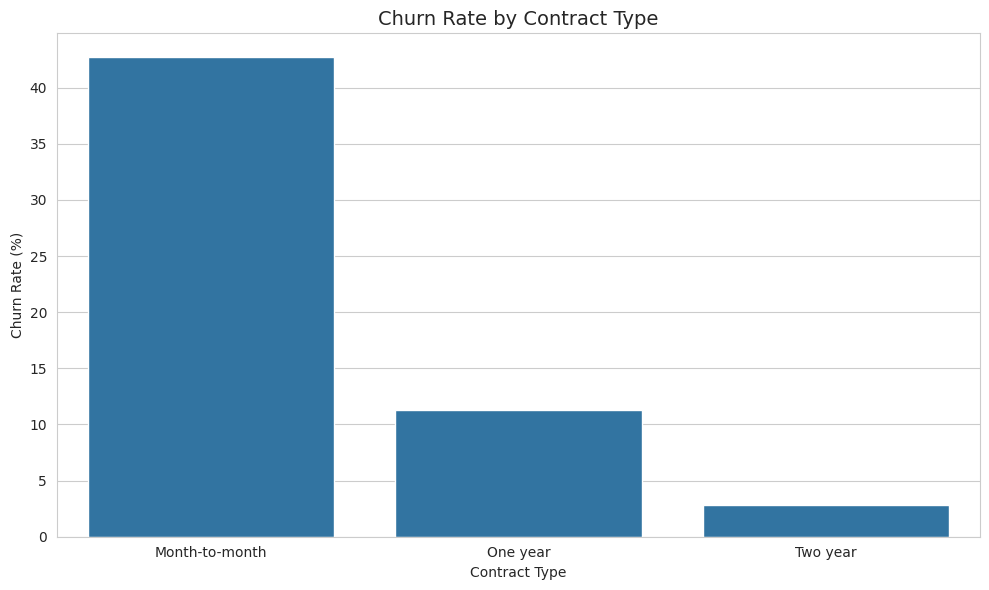

In [35]:
sns.barplot(
    data=contract_churn,
    x="Contract",
    y="ChurnRate"
)

plt.title("Churn Rate by Contract Type", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

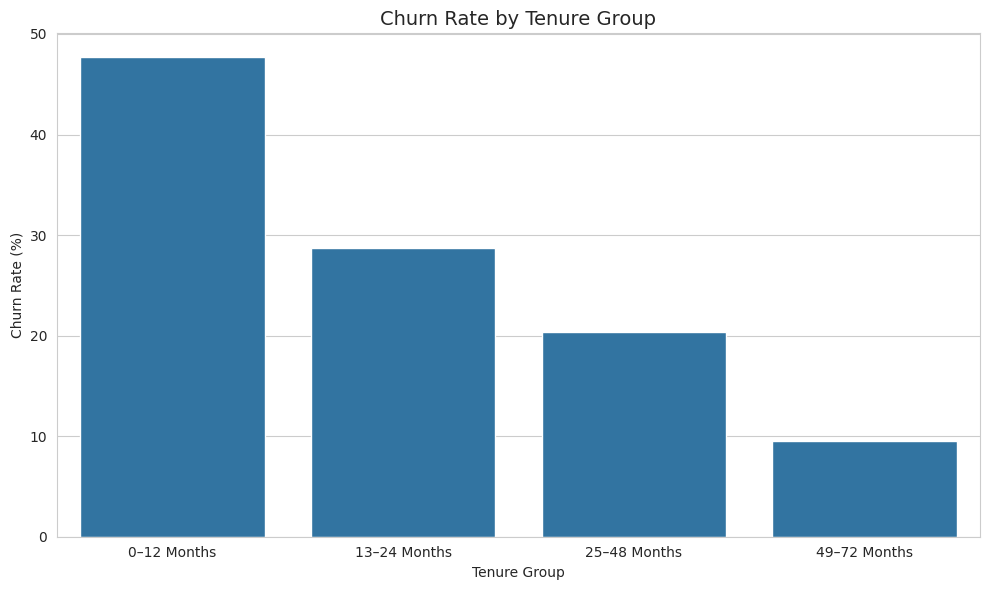

In [36]:
sns.barplot(
    data=tenure_analysis,
    x="TenureGroup",
    y="ChurnRate"
)

plt.title("Churn Rate by Tenure Group", fontsize=14)
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

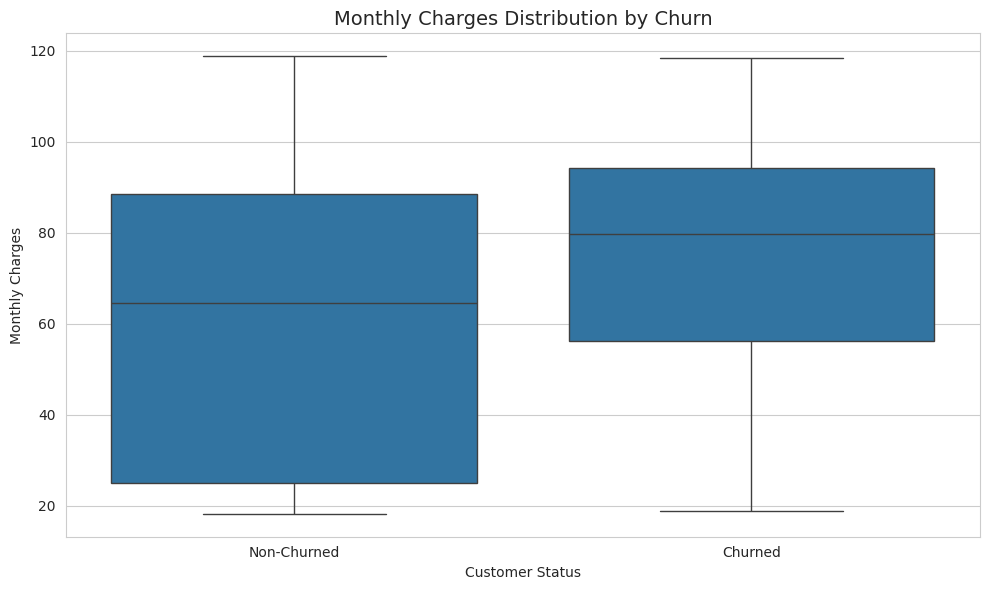

In [40]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.xticks([0, 1], ["Non-Churned", "Churned"])

plt.title("Monthly Charges Distribution by Churn", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

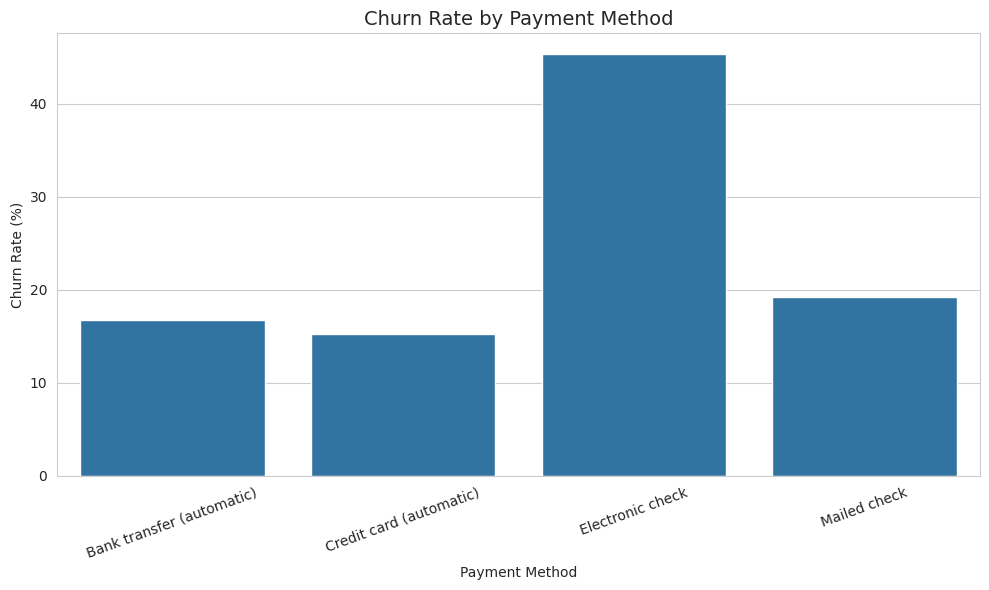

In [41]:
sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRate"
)

plt.title("Churn Rate by Payment Method", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

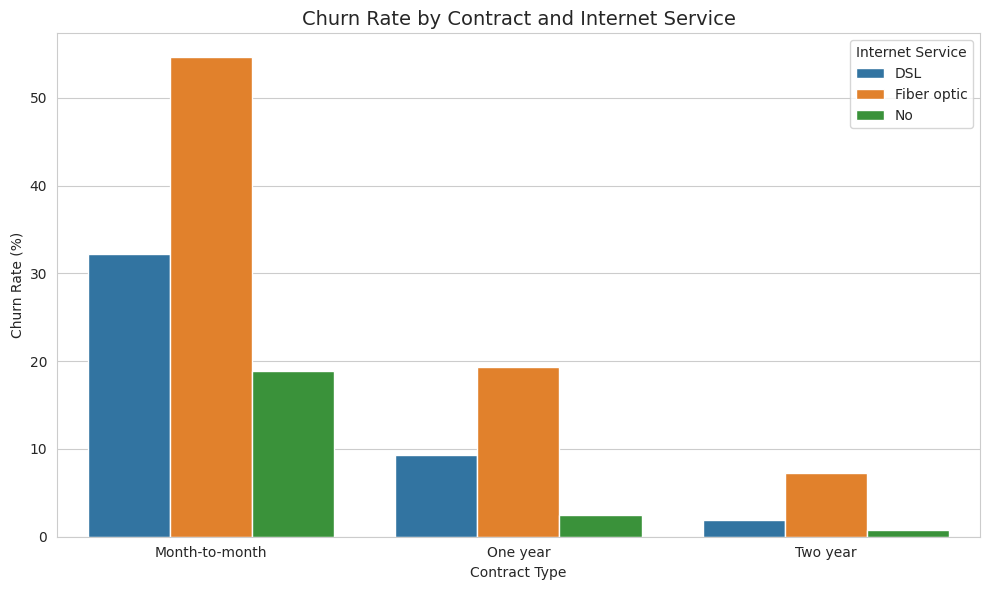

In [43]:
sns.barplot(
    data=contract_internet_analysis,
    x="Contract",
    y="ChurnRate",
    hue="InternetService"
)

plt.title("Churn Rate by Contract and Internet Service", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.legend(title="Internet Service")

plt.tight_layout()
plt.show()